In [17]:
import operator
import requests
import os
import re
from langchain.tools import tool
from langchain_openai import ChatOpenAI
from dotenv import load_dotenv
from IPython.display import Image, display
from langchain_core.messages import SystemMessage,HumanMessage
from langchain_core.tools import tool
from langgraph.prebuilt import ToolNode
from langchain_community.tools.tavily_search import TavilySearchResults
from langgraph.graph import StateGraph,START,END,MessagesState
from typing import TypedDict,Annotated
from pydantic import BaseModel,Field

In [18]:
class FraudState(MessagesState):
    # Core job data
    job_text: str
    suspicious_keyword: Annotated[list[str], operator.add]
    risk_score: int
    tool_call_iteration: int
    
    # Contact metadata
    emailaddress: list[str]
    is_email_free: bool

    # Website verification
    website_link: list[str]
    website_available: bool
    website_content_score: int  # 0-40 based on corporate info, address, careers
    valide_website: bool

    # LinkedIn verification
    linkedin_score: int        # 0-20 based on employee count & official presence
    linkedin_profile: bool     # Fixed lowercase 'l' for consistency
    
    # Audit log
    evidance_log: Annotated[list[str], operator.add]
    final_verdict: str


In [19]:
class SuspiciousPhraseExtractor(BaseModel):
    """Schema to force the llm to output a clean list of suspicious phrases"""
    phrases:list[str]=Field(description="List of exact phrases extracted from the text that indicate upfront payments, unrealistic salary promises, or pressure tactics."
    )

class ContentVerification(BaseModel):
    is_legitimate_content: bool = Field(description="True if website content matches official corporate operations.")
    content_score: int = Field(description="Score between 0-40 based on corporate info, address, and career listings.")
    reasoning: str = Field(description="Explanation of how the content was evaluated and why it was deemed legitimate or not.")
    is_valid_profile: bool = Field(description="True if an official LinkedIn company page exists.")
    linkedin_score: int = Field(description="Score between 0-20 based on employee count and official presence.")    


In [20]:

load_dotenv()
@tool
def job_post_search_tool(company_name: str, website_link: str = "") -> str:
    """Searches LangSearch to verify if a hiring company has a real website 
    or registered online footprint in Bangladesh, and if they are actively 
    hiring for the position mentioned in the job circular.
    
    Args:
        company_name: Name of the hiring company extracted from the job circular.
        website_link: Optional website link found in the post (e.g., 'companybd.com').
    """
    api_key = os.getenv("LANGSEARCH_API_KEY")
    if not api_key:
        return "Error: LANGSEARCH_API_KEY environment variable is not set."

    # Build the search query
    if website_link:
        search_query = f"{company_name} OR {website_link} official site Bangladesh and recent job postings"
    else:
        search_query = f"{company_name} official site Bangladesh and recent job postings"

    url = "https://api.langsearch.com/v1/web-search"
    headers = {
        "Authorization": f"Bearer {api_key}",
        "Content-Type": "application/json"
    }
    payload = {
        "query": search_query,
        "freshness": "noLimit",
        "summary": True
    }

    try:
        response = requests.post(url, headers=headers, json=payload, timeout=10)
        
        if response.status_code != 200:
            return f"Search failed with status code {response.status_code}: {response.text}"

        data = response.json()
        
        # Check if response code is valid
        if data.get("code") != 200 or not data.get("data"):
            return f"No relevant search findings found for query [{search_query}]."

        # Parse web pages returned by LangSearch
        web_pages = data["data"].get("webPages", {}).get("value", [])[:3]

        if not web_pages:
            return f"No web page results found for query [{search_query}]."

        summary = f"Search Findings for query [{search_query}]:\n"
        for idx, result in enumerate(web_pages):
            title = result.get("name", "No title")
            page_url = result.get("url", "No URL")
            snippet = result.get("snippet", "No content")
            summary += f"Result {idx+1}:\nTitle: {title}\nURL: {page_url}\nSnippet: {snippet}\n\n"

        return summary

    except Exception as e:
        return f"Search failed for '{search_query}'. Error details: {str(e)}"

In [21]:

load_dotenv()

@tool
def linkedin_search_tool(company_name: str) -> str:
    """Searches LangSearch to verify if a hiring company has an official LinkedIn page.
    
    Args:
        company_name: Name of the hiring company extracted from the job circular.
    """
    api_key = os.getenv("LANGSEARCH_API_KEY")
    if not api_key:
        return "Error: LANGSEARCH_API_KEY is missing from your .env file."

    search_query = f"{company_name} official LinkedIn page"
    url = "https://api.langsearch.com/v1/web-search"
    
    headers = {
        "Authorization": f"Bearer {api_key}",
        "Content-Type": "application/json"
    }
    payload = {
        "query": search_query,
        "freshness": "noLimit",
        "summary": True
    }

    try:
        response = requests.post(url, headers=headers, json=payload, timeout=10)
        
        if response.status_code != 200:
            return f"LinkedIn search failed with status code {response.status_code}: {response.text}"

        data = response.json()

        if data.get("code") != 200 or not data.get("data"):
            return f"No LinkedIn search findings found for query [{search_query}]."

        # Extract web results
        web_pages = data["data"].get("webPages", {}).get("value", [])[:3]

        if not web_pages:
            return f"No web results returned for query [{search_query}]."

        summary = f"LinkedIn Search Findings for query [{search_query}]:\n"
        for idx, result in enumerate(web_pages):
            title = result.get("name", "No title")
            page_url = result.get("url", "No URL")
            snippet = result.get("snippet", "No content")
            summary += f"Result {idx+1}:\nTitle: {title}\nURL: {page_url}\nSnippet: {snippet}\n\n"

        return summary

    except Exception as e:
        return f"LinkedIn search failed for '{search_query}'. Error details: {str(e)}"

In [22]:
tools = [job_post_search_tool, linkedin_search_tool]
tool_node = ToolNode(tools)

In [23]:
llm=llm = ChatOpenAI(
    model="openai/gpt-oss-120b",
    api_key=os.environ.get("GROQ_API_KEY"),
    base_url="https://api.groq.com/openai/v1",
    temperature=0,
    max_tokens=1024
)
structured_llm=llm.with_structured_output(SuspiciousPhraseExtractor)
structured_llm_content_verification=llm.with_structured_output(ContentVerification)
llm_with_tools=llm.bind_tools(tools)

In [24]:
def input_normalizer_node(state:FraudState):
    
    email_pattern=r'[a-zA-Z0-9._%+-]+@[a-zA-Z0-9.-]+\.[a-zA-Z]{2,}'
    raw_email=list(re.findall(email_pattern,state["job_text"]))
    free_email_domains=["gmail.com","yahoo.com","hotmail.com","outlook.com","aol.com"]
    for email in raw_email:
        domain=email.split("@")[-1].lower()
        if domain in free_email_domains:
            state["is_email_free"]=True
        else:
            state["is_email_free"]=False

    website_pattern=r'https?://(?:www\.)?[-a-zA-Z0-9@:%._\+~#=]{1,256}\.[a-zA-Z0-9()]{1,6}\b(?:[-a-zA-Z0-9()@:%_\+.~#?&//=]*)'
    raw_website=list(re.findall(website_pattern,state["job_text"]))  
    if len(raw_website)>0:
        website_available=True
    else:
        website_available=False
              
    job_text=state["job_text"].strip()
    return{
        "job_text":job_text,
        "emailaddress":raw_email,
        "is_email_free":state["is_email_free"],
        "website_link":raw_website,
        "website_available":website_available,
        "evidance_log":[f"Step 1: Extracted emails: {raw_email}, Free email: {state['is_email_free']}, Extracted websites: {raw_website}, Website available: {website_available}"]
    }

In [25]:
def key_word_extractor(state:FraudState):
    """This node extracts suspicious phrases from the job text using the structured LLM."""
    job_text=state["job_text"]
    response:SuspiciousPhraseExtractor=structured_llm.invoke(
        f"You are a recruitment fraud analyst in Bangladesh. Extract any phrases "
        "from this job circular that request money upfront (e.g., bKash, registration fee,Nagad), "
        "offer unrealistic pay for basic skills, or pressure the applicant to act quickly:\n\n"
        f"{job_text}\n\n" "if there are no such phrases,return an empty list.")
    extracted_phrases = getattr(response, "phrases", []) or []
    return{
        "suspicious_keyword":extracted_phrases,
        "evidance_log":[f"Step:2 Extracted suspicious phrases: {extracted_phrases}"]
    }
    

In [26]:
def risk_base_on_keywords_node(state:FraudState):
    """this node investigates the keyword risk and email addresses risk.
    """
    risk_score = 0
    if state["is_email_free"]:
        risk_score+=5
    if not state["website_available"]:
        risk_score+=5

    if len(state["suspicious_keyword"])>5:
        risk_score+=30
    elif(len(state["suspicious_keyword"])<=5 and len(state["suspicious_keyword"])>0):
        risk_score+=len(state["suspicious_keyword"])*6
    else:
        risk_score+=0
    return{
        "risk_score":risk_score,
        "evidance_log":[f"Step:3 Calculated risk score based on keywords and email/website availability: {risk_score}"]
        }
    

In [27]:
def investigator_node(state:FraudState):
    system_prompt=(
        "You are a recruitment fraud investigator for JobShield BD.\n"
        "RULES:\n"
        "1. You MUST verify BOTH the company's official website AND their LinkedIn presence.\n"
        "2. If you have only checked one of them, you MUST invoke a search tool for the missing one.\n"
        "3. Only stop calling tools when you have gathered clear search evidence for BOTH website and LinkedIn."
    )
    current_iteration = state.get("tool_call_iteration", 0)
    messages = [SystemMessage(content=system_prompt)] + state["messages"]
    result=llm_with_tools.invoke(messages)
    new_log_entry=f"Step{current_iteration+3}: Investigation findings:{result.content}"
    return {"messages": [result],
            "tool_call_iteration":current_iteration+1,
            "evidance_log": state.get("evidance_log", []) + [new_log_entry]
            }

In [28]:
def score_formatter_node(state: FraudState):
    """Extracts BOTH website and LinkedIn scores into the unified Pydantic schema."""
    final_report = structured_llm.invoke(state["messages"])
    risk_score=state["risk_score"]+state["website_content_score"]+state["linkedin_score"]
    return {
        "risk_score": risk_score
        }

In [29]:
def router_next(state:FraudState):
    """Determines the next node based on the evaluation results."""
    current_iteration = state.get("tool_call_iteration", 0)
    
    # 1. Guardrail: Exit loop if max iterations reached
    if current_iteration >= 4:
        return "score"
    last_message=state["messages"][-1]
    if hasattr(last_message,"tool_calls") and last_message.tool_calls:
        return "tools"
  
    return "score"

In [ ]:
from langchain_core.messages import SystemMessage, HumanMessage
from typing import Dict, Any

def verdict_node(state: FraudState) -> Dict[str, Any]:
    system_prompt = (
        "You are the Lead Fraud Analyst for JobShield BD. Your job is to render a strict, "
        "structured final verdict on a job posting based ONLY on the provided evidence log.\n\n"
        "STRICT OUTPUT FORMAT RULES:\n"
        "You MUST format your entire response using the following EXACT headers and structure. "
        "Do NOT write generic summaries.\n\n"
        "1. VERDICT & RISK SCORE\n"
        "   - Verdict: [LEGITIMATE | SUSPICIOUS | FRAUDULENT]\n"
        "   - Risk Score: [X]/100\n\n"
        "2. WHY YOU SHOULD NOT APPLY\n"
        "   - Provide clear, direct reasons explaining why the job seeker must avoid this posting "
        "     (e.g., upfront payment demands, free email usage, suspicious payment methods).\n\n"
        "3. ONLINE PRESENCE & VERIFICATION\n"
        "   - Website Status: [Summarize content score and availability. Explicitly state if website is missing/unavailable].\n"
        "   - LinkedIn Status: [Summarize official presence and employee count score. Explicitly state if profile is missing/unavailable].\n\n"
        "4. SUMMARY OF EVIDENCE LOG\n"
        "   - Bullet point key findings extracted during the graph analysis."
    )

    # Extract conversation history or formatted search evidence
    raw_log = state.get("evidance_log", [])
    formatted_evidence = "\n".join(raw_log) if isinstance(raw_log, list) else str(raw_log)
    
    # Fallback to last message content if formatted_evidence is empty
    if not formatted_evidence and state["messages"]:
        formatted_evidence = state["messages"][-1].content

    user_prompt = f"Analyze the following gathered evidence and issue your final verdict:\n\n{formatted_evidence}"

    messages = [
        SystemMessage(content=system_prompt),
        HumanMessage(content=user_prompt)
    ]

    # Call the LLM (without tools) to generate the final decision
    response = llm.invoke(messages)

    # Store final verdict and append the final AI response to state
    return {
        "messages": [response],
        "final_verdict": response.content
    }

Graph Assembly

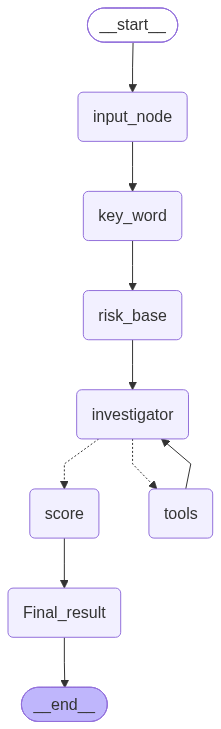

In [31]:
builder=StateGraph(FraudState)
builder.add_node("input_node",input_normalizer_node)
builder.add_node("key_word",key_word_extractor)
builder.add_node("risk_base",risk_base_on_keywords_node)
builder.add_node("investigator",investigator_node)
builder.add_node("score",score_formatter_node)
builder.add_node("Final_result",verdict_node)
builder.add_node("tools",ToolNode(tools))



builder.add_edge(START,"input_node")
builder.add_edge("input_node","key_word")
builder.add_edge("key_word","risk_base")
builder.add_edge("risk_base","investigator")
builder.add_conditional_edges(
    "investigator",
    router_next,{
        "tools": "tools",
        "score": "score"
    }
)
builder.add_edge("tools","investigator")
builder.add_edge("score","Final_result")
builder.add_edge("Final_result",END)


graph=builder.compile()


# Display the graph image inline
display(Image(graph.get_graph().draw_mermaid_png()))


In [ ]:
from langchain_core.messages import HumanMessage

sample_job_posting = """
Job Title: Remote Data Entry Specialist
Company: Global Tech Solutions BD
Salary: $5,000 / month (Weekly Payout via Crypto/Wire)
Requirements: 
- No experience required. 
- Must pay a $50 mandatory background verification fee before onboarding.
Website: http://globaltech-solutions-bd-fake.com
LinkedIn: Not provided in posting.
Description: Send your CV and personal details to hr-globaltech@gmail.com to apply instantly.
"""

initial_state = {
    "messages": [HumanMessage(content=sample_job_posting)],
    "job_text": sample_job_posting,
    "suspicious_keyword": [],
    "risk_score": 0,
    "tool_call_iteration": 0,
    "emailaddress": [],
    "is_email_free": False,
    "website_link": [],
    "website_available": False,
    "website_content_score": 0,
    "valide_website": False,
    "linkedin_score": 0,
    "linkedin_profile": False,
    "evidance_log": [],
    "final_verdict": ""
}

print("==================================================")
print("        JOB SHIELD BD — AGENT STREAM TRACE        ")
print("==================================================\n")

step_counter = 1

for output in graph.stream(initial_state):
    for node_name, state_update in output.items():
        print(f"STEP {step_counter}: Node [{node_name}] Executed")
        print("-" * 50)
        
        # 1. Print Evidence Log updates
        if "evidance_log" in state_update and state_update["evidance_log"]:
            print(f"  • Action/Log : {state_update['evidance_log'][-1]}")

        # 2. Print Extracted Keywords (if updated at key_word node)
        if "suspicious_keyword" in state_update and state_update["suspicious_keyword"]:
            print(f"  • Keywords   : {state_update['suspicious_keyword']}")

        # 3. Print Risk Score (if updated)
        if "risk_score" in state_update and state_update["risk_score"] > 0:
            print(f"  • Risk Score : {state_update['risk_score']}/100")

        # 4. Print Tool Execution Calls (if triggered by investigator)
        if "messages" in state_update and state_update["messages"]:
            last_msg = state_update["messages"][-1]
            if hasattr(last_msg, "tool_calls") and last_msg.tool_calls:
                tool_names = [t["name"] for t in last_msg.tool_calls]
                print(f"  • Tools Used : {tool_names}")

        # 5. Print Final Verdict banner
        if "final_verdict" in state_update and state_update["final_verdict"]:
            print("\n==================================================")
            print("                 FINAL VERDICT                    ")
            print("==================================================")
            print(state_update["final_verdict"])
            print("==================================================")
            print(state_update["risk_score"])
            print("==================================================")

        print("\n")
        step_counter += 1

        JOB SHIELD BD — AGENT STREAM TRACE        

STEP 1: Node [input_node] Executed
--------------------------------------------------
  • Action/Log : Step 1: Extracted emails: ['hr-globaltech@gmail.com'], Free email: True, Extracted websites: ['http://globaltech-solutions-bd-fake.com'], Website available: True


STEP 2: Node [key_word] Executed
--------------------------------------------------
  • Action/Log : Step:2 Extracted suspicious phrases: ['Must pay a $50 mandatory background verification fee before onboarding.', 'Salary: $5,000 / month (Weekly Payout via Crypto/Wire)']
  • Keywords   : ['Must pay a $50 mandatory background verification fee before onboarding.', 'Salary: $5,000 / month (Weekly Payout via Crypto/Wire)']


STEP 3: Node [risk_base] Executed
--------------------------------------------------
  • Action/Log : Step:3 Calculated risk score based on keywords and email/website availability: 17
  • Risk Score : 17/100


STEP 4: Node [investigator] Executed
---------